<a href="https://colab.research.google.com/github/ecloguehwang/2026-Seojinhyeop-Workshop/blob/main/%EC%88%98%EC%8B%9C%EA%B5%90%EA%B3%BC%EC%A2%85%ED%95%A9%EB%82%98%EC%B9%A8%EB%B0%98_2027%ED%95%99%EB%85%84%EB%8F%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#colab에서 matplotlib와 sns 라이브러리 그래프 한글을 깨지지 않게 하는 법 - 실행 후 런타임 재실행
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 11 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (8,938 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122797 files and

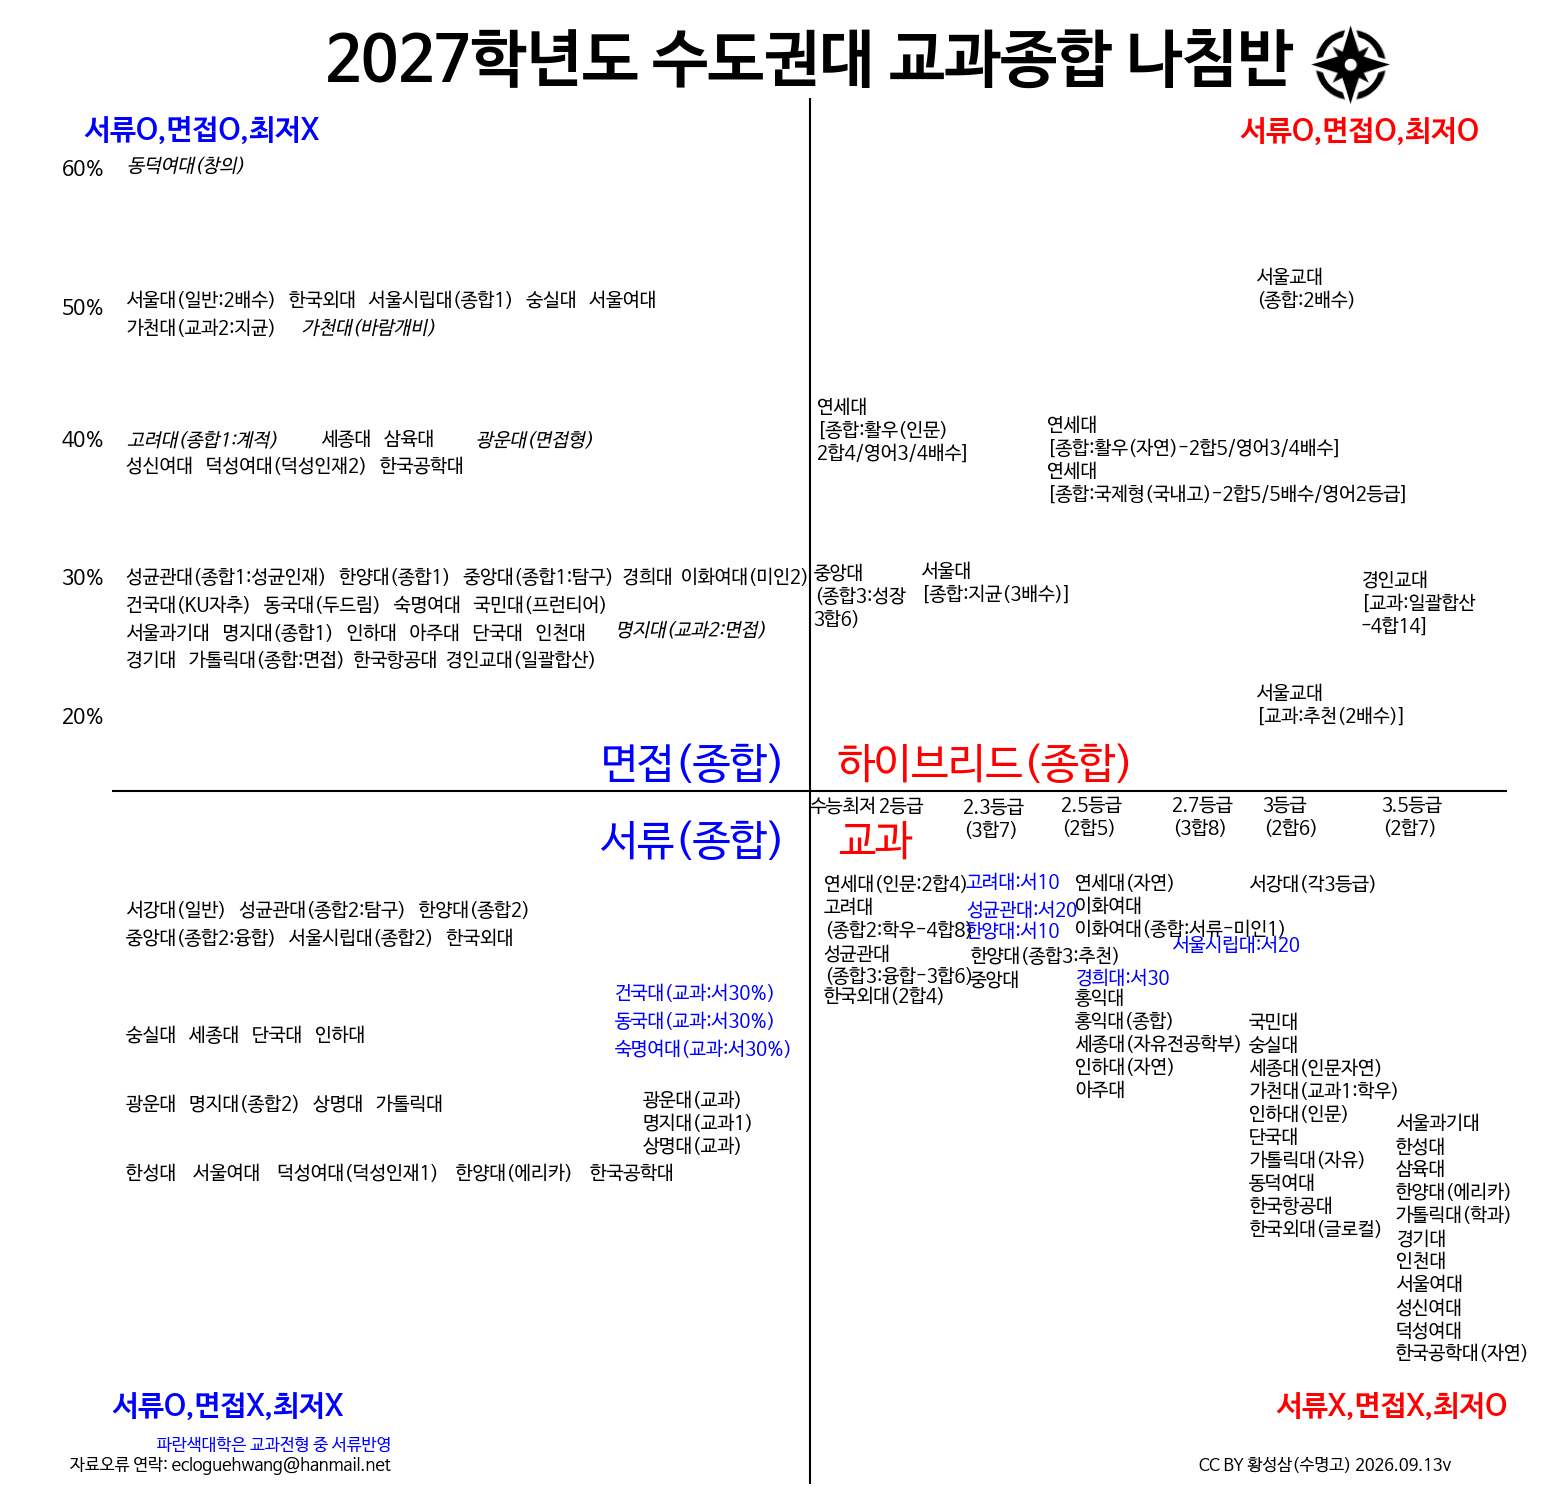

In [ ]:
#새버전_ 수능이전 면접대학 이텔릭으로 표현

import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.textpath import TextPath
from matplotlib.font_manager import FontProperties
from matplotlib.patches import PathPatch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import time
from datetime import datetime
import pytz


#matplotlib에서 한글구현
plt.rc('font', family='NanumBarunGothic')

#그래프 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


# 서울의 현재시간
kst = pytz.timezone('Asia/Seoul')
current_datetime = datetime.now(kst).strftime('%Y.%m.%d')

# 그래프 크기 설정 (dpi를 명시적으로 고정 - 이탤릭 위치 계산의 정확도를 위해 중요)
FIG_DPI = 150
fig, ax = plt.subplots(figsize=(12, 12), dpi=FIG_DPI)


# ============================================================
# 한글 폰트는 대부분 '이탤릭 글리프'가 없어서 fontstyle='italic'을
# 줘도 matplotlib이 이를 무시하고 정자체로 렌더링합니다.
# (Text 객체에 rotation/transform을 걸어도 글자 "모양"은 기울지 않고
#  위치(anchor)만 이동합니다. 글리프는 항상 수평으로 그려집니다.)
#
# 그래서 텍스트를 TextPath(글자 윤곽선 벡터 패스)로 변환한 뒤
# PathPatch로 그리면서 skew_deg()로 강제로 기울이는 "faux italic" 방식을
# 사용합니다. 실제 글자 윤곽선 자체를 변형하므로 한글에서도
# 확실하게 기울어진 모양으로 렌더링됩니다.
# ============================================================
def italic_text(ax, x, y, text, fontsize=9, color='black', skew_deg=12,
                 ha='left', fontproperties=None, zorder=3):
    """
    ax.text()와 같은 감각으로 사용하는 '진짜' 이탤릭(기울임) 텍스트 함수.
    - x, y         : 데이터 좌표 (ax.text와 동일)
    - fontsize     : 폰트 크기(pt)
    - skew_deg     : 기울기 각도(값이 클수록 더 많이 기울어짐, 보통 10~15 권장)
    - ha           : 'left' | 'center' | 'right'
    - fontproperties : FontProperties 지정 시 해당 폰트 사용
                       (지정하지 않으면 현재 rcParams의 기본 폰트를 사용)
    """
    fig = ax.figure
    fp = fontproperties if fontproperties is not None else FontProperties(
        family=plt.rcParams['font.family'], size=fontsize)

    tp = TextPath((0, 0), text, prop=fp, size=fontsize)
    bbox = tp.get_extents()

    dx = 0
    if ha == 'center':
        dx = -bbox.width / 2
    elif ha == 'right':
        dx = -bbox.width

    # 데이터 좌표 (x, y) -> 화면 픽셀 좌표로 변환
    px, py = ax.transData.transform((x, y))

    # TextPath의 좌표 단위는 "포인트" 이므로, 포인트->픽셀 배율 = dpi/72
    pt_to_px = fig.dpi / 72.0

    trans = (mtransforms.Affine2D()
             .translate(dx, 0)       # 정렬(ha) 보정 - 포인트 단위에서 처리
             .skew_deg(skew_deg, 0)  # 글자를 비스듬히 기울임 (핵심)
             .scale(pt_to_px)        # 포인트 -> 픽셀 단위 환산
             .translate(px, py))     # 최종 화면 위치로 이동

    patch = PathPatch(tp, transform=trans, color=color, lw=0, zorder=zorder)
    fig.add_artist(patch)
    return patch


# 사분면 구분선 그리기
ax.axhline(y=0.5, color='black', linewidth=1)
ax.axvline(x=0.5, color='black', linewidth=1)


# 사분면 제목 추가
ax.text(0.35, 0.51, '면접(종합)', fontsize=20, color='blue')
ax.text(0.52, 0.51, '하이브리드(종합)', fontsize=20, color='red')
ax.text(0.35, 0.455, '서류(종합)', fontsize=20, color='blue')
ax.text(0.52, 0.455, '교과', fontsize=20, color='red')


# 최저 없음 / 있음 표시
ax.text(-0.02, 0.971, '서류O,면접O,최저X', fontsize=14, color='blue', weight='bold', ha='left')
ax.text(0, 0.05, '서류O,면접X,최저X', fontsize=14, color='blue', weight='bold', ha='left')
ax.text(0.98, 0.97, '서류O,면접O,최저O', fontsize=14, color='red', weight='bold', ha='right')
ax.text(1, 0.05, '서류X,면접X,최저O', fontsize=14, color='red', weight='bold', ha='right')


#파란색 대학 설명
ax.text(0.2, 0.025, f'파란색대학은 교과전형 중 서류반영', fontsize=8, color='blue', ha='right')


# 자료 오류연락
ax.text(0.2, 0.01, f'자료오류 연락: ecloguehwang@hanmail.net', fontsize=8, color='black', ha='right')


# 저작자 표시
ax.text(0.96, 0.01, f'CC BY 황성삼(수명고) {current_datetime}v', fontsize=8, color='black', ha='right')


# Y축 라벨(값)은 유지하고 눈금만 제거
ax.set_yticks([0.555, 0.655, 0.755, 0.85, 0.95])
ax.set_yticklabels(['20%', '30%', '40%', '50%', '60%'])
ax.tick_params(axis='y', length=0)


# X축 tick label 제거
ax.set_xticks([])


# 파란색으로 표시할 대학 및 좌표 (정확히 지정)
blue_placements = [
    (0.36, 0.35, '건국대(교과:서30%)'),
    (0.36, 0.33, '동국대(교과:서30%)'),
    (0.36, 0.31, '숙명여대(교과:서30%)'),
    (0.612, 0.43, '고려대:서10'),
    (0.612, 0.41, '성균관대:서20'),
    (0.612, 0.395, '한양대:서10'),
    (0.69, 0.361, '경희대:서30'),
    (0.76, 0.385, '서울시립대:서20')
]

for x, y, text in blue_placements:
    ax.text(x, y, text, fontsize= 9, color='blue')


# ============================================================
# 이탤릭(수능 이전 면접대학)으로 표시할 항목
# 원래 한 줄에 여러 대학이 붙어 있던 것 중 '고려대(종합1:계적)'만
# 분리해서 진짜 이탤릭체로 표시
# ============================================================
italic_placements = [
    (-0.07, 0.617, '고려대(종합1:계적)'),
    (0.18, 0.617, '광운대(면접형)'),
    (0.055, 0.698,   '가천대(바람개비)' ),
    (-0.07, 0.815, '동덕여대(창의)'),
    (0.28, 0.48, '명지대(교과2:면접)')
]

for x, y, text in italic_placements:
    italic_text(ax, x, y, text, fontsize=9, color='black', skew_deg=12)


# 나머지 대학 및 전형 정보 (검은색으로 표시)
placements = [

    (0.01, 0.85, '서울대(일반:2배수)   한국외대   서울시립대(종합1)   숭실대   서울여대'),
    (0.01, 0.83,  '가천대(교과2:지균)'), #가천대(바람개비) 이동
    (0.15, 0.75, '세종대   삼육대'),  # '고려대(종합1:계적)', 광운대(면접형)은 이탤릭으로 분리했으므로 x시작점을 오른쪽으로 이동
    (0.01, 0.73, '성신여대   덕성여대(덕성인재2)   한국공학대'),
    (0.01, 0.65, '성균관대(종합1:성균인재)   한양대(종합1)   중앙대(종합1:탐구)  경희대  이화여대(미인2)'),
    (0.01, 0.63, '건국대(KU자추)   동국대(두드림)   숙명여대   국민대(프런티어)'),
    (0.01, 0.61, '서울과기대   명지대(종합1)   인하대   아주대   단국대   인천대'),
    (0.01, 0.59, '경기대   가톨릭대(종합:면접)  한국항공대  경인교대(일괄합산)'), #명지대(교과2:면접) 이동
    (0.505, 0.74, '연세대\n[종합:활우(인문)\n2합4/영어3/4배수]'),
    (0.82, 0.85, '서울교대\n(종합:2배수)'),
    (0.67, 0.71, '연세대\n[종합:활우(자연)-2합5/영어3/4배수]\n연세대\n[종합:국제형(국내고)-2합5/5배수/영어2등급]'),
    (0.503, 0.62, '중앙대\n(종합3:성장\n3합6)'),
    (0.58, 0.638, '서울대\n[종합:지균(3배수)]'),
    (0.82, 0.550, '서울교대\n[교과:추천(2배수)]'),
    (0.895, 0.615, '경인교대\n[교과:일괄합산\n-4합14]'),




    (0.01, 0.41, '서강대(일반)   성균관대(종합2:탐구)   한양대(종합2)'),
    (0.01, 0.39, '중앙대(종합2:융합)   서울시립대(종합2)   한국외대'),
    (0.01, 0.32, '숭실대   세종대   단국대   인하대'),
    (0.01, 0.27, '광운대   명지대(종합2)   상명대   가톨릭대'),

    (0.01, 0.22, '한성대    서울여대    덕성여대(덕성인재1)    한양대(에리카)    한국공학대'),

    (0.38, 0.24, '광운대(교과)\n명지대(교과1)\n상명대(교과)'),

    (0.50, 0.485, '수능최저'),
    (0.55, 0.485, '2등급'),
    (0.61, 0.468, '2.3등급\n(3합7)'),
    (0.68, 0.469, '2.5등급\n(2합5)'),
    (0.76, 0.469, '2.7등급\n(3합8)'),
    (0.825, 0.469, '3등급\n(2합6)'),
    (0.91, 0.469, '3.5등급\n(2합7)')

]

for x, y, text in placements:
    ax.text(x, y, text, fontsize= 9, color='black')

# 추가 대학 및 전형 정보 (검은색으로 표시, blue_placements로 이미 처리된 부분 제외)
placements02 = [
    (0.51, 0.362, '연세대(인문:2합4)\n고려대\n(종합2:학우-4합8)\n성균관대\n(종합3:융합-3합6)'),
    (0.51, 0.348, '한국외대(2합4)'),
    (0.615, 0.36, '한양대(종합3:추천)\n중앙대'),
    (0.69, 0.28, '연세대(자연)\n이화여대\n이화여대(종합:서류-미인1)\n\n\n홍익대\n홍익대(종합)\n세종대(자유전공학부)\n인하대(자연)\n아주대'),

    (0.815, 0.18, '서강대(각3등급)\n\n\n\n\n\n국민대\n숭실대\n세종대(인문자연)\n가천대(교과1:학우)\n인하대(인문)\n단국대\n가톨릭대(자유)\n동덕여대\n한국항공대\n한국외대(글로컬)'),
    (0.92, 0.09, '서울과기대\n한성대\n삼육대\n한양대(에리카)\n가톨릭대(학과)\n경기대\n인천대\n서울여대\n성신여대\n덕성여대\n한국공학대(자연)'),
]

for x, y, text in placements02:
    ax.text(x, y, text, fontsize= 9, color='black')

ax.set_title('2027학년도 수도권대 교과종합 나침반', fontsize= 30, weight='bold')


# 이미지 삽입
image_path = '/content/drive/MyDrive/python/jinhak/image/compass.png'
image = plt.imread(image_path)
imagebox = OffsetImage(image, zoom= 0.5)
ab = AnnotationBbox(imagebox, (0.92, 1.06), xycoords='axes fraction', box_alignment=(1, 1), pad=0, frameon=False)
ax.add_artist(ab)


# 그래프 테두리(Spines) 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# 그래프 저장 (사진 파일로 결과 출력)
# 주의: savefig의 dpi는 위 FIG_DPI와 반드시 일치시켜야 이탤릭 텍스트
#       위치/크기가 어긋나지 않습니다.
#path2 = '/content/drive/MyDrive/python/jinhak/'
#plt.savefig(f'{path2}2027_수시나침반.png', bbox_inches='tight', dpi=FIG_DPI)

plt.show()

### 성균관대(종합: 융합) 수능최저(3합6) 추가
### 중앙대(종합: 성장) 수능최저(3합6) 추가
### 홍익대(교과), 홍익대(종합): 3합8에서 2합5으로 변경
### 숭실대(종합): 서류형(154명)
### 세종대(교과): 인문자연은 2합6, 자유전공은 2합5
### 단국대(종합): 서류형 추가
### 인하대(종합): 서류형 추가
### 아주대(교과): 2합6에서 2합5로 변경
###숙명여대(교과): 2합6에서 최저폐지하고 서류30%로 바뀜
###숙명여대(종합): 면접40%에서 30%로 변경
###동덕여대(교과): 2합7에서 2합6으로 바뀜
###한국공학대(종합): 서류형 신설

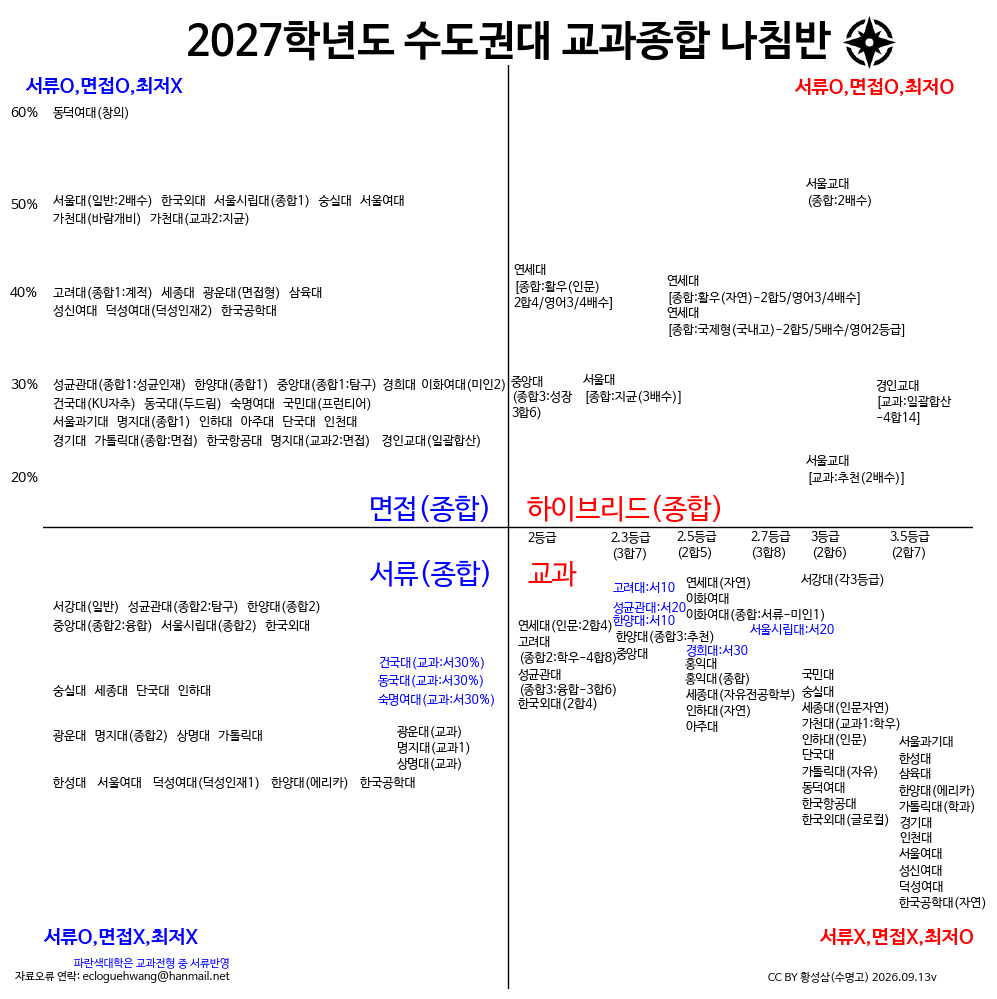

In [ ]:
#오리지널 코드

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import time
from datetime import datetime
import pytz


#matplotlib에서 한글구현
plt.rc('font', family='NanumBarunGothic')

#그래프 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


# 서울의 현재시간
kst = pytz.timezone('Asia/Seoul')
current_datetime = datetime.now(kst).strftime('%Y.%m.%d')

# 그래프 크기 설정
fig, ax = plt.subplots(figsize=(12, 12))


# 사분면 구분선 그리기
ax.axhline(y=0.5, color='black', linewidth=1)
ax.axvline(x=0.5, color='black', linewidth=1)


# 사분면 제목 추가
ax.text(0.35, 0.51, '면접(종합)', fontsize=20, color='blue')
ax.text(0.52, 0.51, '하이브리드(종합)', fontsize=20, color='red')
ax.text(0.35, 0.44, '서류(종합)', fontsize=20, color='blue')
ax.text(0.52, 0.44, '교과', fontsize=20, color='red')


# 최저 없음 / 있음 표시
ax.text(-0.02, 0.971, '서류O,면접O,최저X', fontsize=14, color='blue', weight='bold', ha='left')
ax.text(0, 0.05, '서류O,면접X,최저X', fontsize=14, color='blue', weight='bold', ha='left')
ax.text(0.98, 0.97, '서류O,면접O,최저O', fontsize=14, color='red', weight='bold', ha='right')
ax.text(1, 0.05, '서류X,면접X,최저O', fontsize=14, color='red', weight='bold', ha='right')


#파란색 대학 설명
ax.text(0.2, 0.025, f'파란색대학은 교과전형 중 서류반영', fontsize=8, color='blue', ha='right')


# 자료 오류연락
ax.text(0.2, 0.01, f'자료오류 연락: ecloguehwang@hanmail.net', fontsize=8, color='black', ha='right')


# 저작자 표시
ax.text(0.96, 0.01, f'CC BY 황성삼(수명고) {current_datetime}v', fontsize=8, color='black', ha='right')


# Y축 라벨(값)은 유지하고 눈금만 제거
ax.set_yticks([0.555, 0.655, 0.755, 0.85, 0.95])  # Y축 위치 설정
ax.set_yticklabels(['20%', '30%', '40%', '50%', '60%'])  # Y축 라벨 설정
ax.tick_params(axis='y', length=0)  # Y축 눈금 선 제거


# X축 tick label 제거
ax.set_xticks([])  # X축 눈금 제거


# 파란색으로 표시할 대학 및 좌표 (정확히 지정)
blue_placements = [
    (0.36, 0.35, '건국대(교과:서30%)'),  # 예: 기존 좌표 (0.35, 0.35)에서 건국대(교과)만 파란색
    (0.36, 0.33, '동국대(교과:서30%)'),  # 예: 동국대(교과)의 새로운 좌표 (조정 필요)
    (0.36, 0.31, '숙명여대(교과:서30%)'),
    (0.612, 0.43, '고려대:서10'),   # 예: placements02에서 (0.6, 0.36)의 첫 줄
    (0.612, 0.41, '성균관대:서20'), # 예: 두 번째 줄 (조정 필요)
    (0.612, 0.395, '한양대:서10'),   # 예: 세 번째 줄 (조정 필요)
    (0.69, 0.363, '경희대:서30'),  # 예: placements02에서 (0.68, 0.28)의 두 번째 줄
    (0.76, 0.385, '서울시립대:서20')
]

# 파란색 텍스트 추가
for x, y, text in blue_placements:
    ax.text(x, y, text, fontsize= 9, color='blue')


# 나머지 대학 및 전형 정보 (검은색으로 표시)
placements = [
    (0.01, 0.945, '동덕여대(창의)'),
    (0.01, 0.85, '서울대(일반:2배수)   한국외대   서울시립대(종합1)   숭실대   서울여대'),
    (0.01, 0.83, '가천대(바람개비)   가천대(교과2:지균)'),
    (0.01, 0.75, '고려대(종합1:계적)   세종대   광운대(면접형)   삼육대'),
    (0.01, 0.73, '성신여대   덕성여대(덕성인재2)   한국공학대'),
    (0.01, 0.65, '성균관대(종합1:성균인재)   한양대(종합1)   중앙대(종합1:탐구)  경희대  이화여대(미인2)'),
    (0.01, 0.63, '건국대(KU자추)   동국대(두드림)   숙명여대   국민대(프런티어)'),
    (0.01, 0.61, '서울과기대   명지대(종합1)   인하대   아주대   단국대   인천대'),
    (0.01, 0.59, '경기대   가톨릭대(종합:면접)   한국항공대   명지대(교과2:면접)    경인교대(일괄합산)'),
    (0.505, 0.74, '연세대\n[종합:활우(인문)\n2합4/영어3/4배수]'),
    (0.82, 0.85, '서울교대\n(종합:2배수)'),
    (0.67, 0.71, '연세대\n[종합:활우(자연)-2합5/영어3/4배수]\n연세대\n[종합:국제형(국내고)-2합5/5배수/영어2등급]'),
    (0.503, 0.62, '중앙대\n(종합3:성장\n3합6)'),
    (0.58, 0.638, '서울대\n[종합:지균(3배수)]'),
    (0.82, 0.550, '서울교대\n[교과:추천(2배수)]'),
    (0.895, 0.615, '경인교대\n[교과:일괄합산\n-4합14]'),




    (0.01, 0.41, '서강대(일반)   성균관대(종합2:탐구)   한양대(종합2)'),
    (0.01, 0.39, '중앙대(종합2:융합)   서울시립대(종합2)   한국외대'),
    (0.01, 0.32, '숭실대   세종대   단국대   인하대'),
    (0.01, 0.27, '광운대   명지대(종합2)   상명대   가톨릭대'),

    (0.01, 0.22, '한성대    서울여대    덕성여대(덕성인재1)    한양대(에리카)    한국공학대'),

    (0.38, 0.24, '광운대(교과)\n명지대(교과1)\n상명대(교과)'),


    (0.52, 0.485, '2등급'),
    (0.61, 0.468, '2.3등급\n(3합7)'),
    (0.68, 0.469, '2.5등급\n(2합5)'),
    (0.76, 0.469, '2.7등급\n(3합8)'),
    (0.825, 0.469, '3등급\n(2합6)'),
    (0.91, 0.469, '3.5등급\n(2합7)')

]

# 검은색 텍스트 추가
for x, y, text in placements:
    ax.text(x, y, text, fontsize= 9, color='black')

# 추가 대학 및 전형 정보 (검은색으로 표시, blue_placements로 이미 처리된 부분 제외)
placements02 = [
    (0.51, 0.32, '연세대(인문:2합4)\n고려대\n(종합2:학우-4합8)\n성균관대\n(종합3:융합-3합6)'),
    (0.51, 0.305, '한국외대(2합4)'),
    (0.615, 0.36, '한양대(종합3:추천)\n중앙대'),  # "고려대", "성균관대", "한양대"는 blue_placements로 처리
    (0.69, 0.28, '연세대(자연)\n이화여대\n이화여대(종합:서류-미인1)\n\n\n홍익대\n홍익대(종합)\n세종대(자유전공학부)\n인하대(자연)\n아주대'),  # "경희대"는 blue_placements로 처리

    (0.815, 0.18, '서강대(각3등급)\n\n\n\n\n\n국민대\n숭실대\n세종대(인문자연)\n가천대(교과1:학우)\n인하대(인문)\n단국대\n가톨릭대(자유)\n동덕여대\n한국항공대\n한국외대(글로컬)'),
    (0.92, 0.09, '서울과기대\n한성대\n삼육대\n한양대(에리카)\n가톨릭대(학과)\n경기대\n인천대\n서울여대\n성신여대\n덕성여대\n한국공학대(자연)'),
]

# 검은색 텍스트 추가
for x, y, text in placements02:
    ax.text(x, y, text, fontsize= 9, color='black')

# 그래프 제목 설정
ax.set_title('2027학년도 수도권대 교과종합 나침반', fontsize= 30, weight='bold')



# 이미지 삽입
image_path = '/content/drive/MyDrive/python/jinhak/image/compass.png'
image = plt.imread(image_path)
imagebox = OffsetImage(image, zoom= 0.5)  # zoom으로 이미지 크기 조정
ab = AnnotationBbox(imagebox, (0.92, 1.06), xycoords='axes fraction', box_alignment=(1, 1), pad=0, frameon=False)
ax.add_artist(ab)


# 그래프 테두리(Spines) 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# 그래프 저장 (사진 파일로 결과 출력)
path2 = '/content/drive/MyDrive/python/jinhak/'
#plt.savefig(f'{path2}2027_수시나침반.png', bbox_inches='tight', dpi=300)

# 그래프 표시
plt.show()

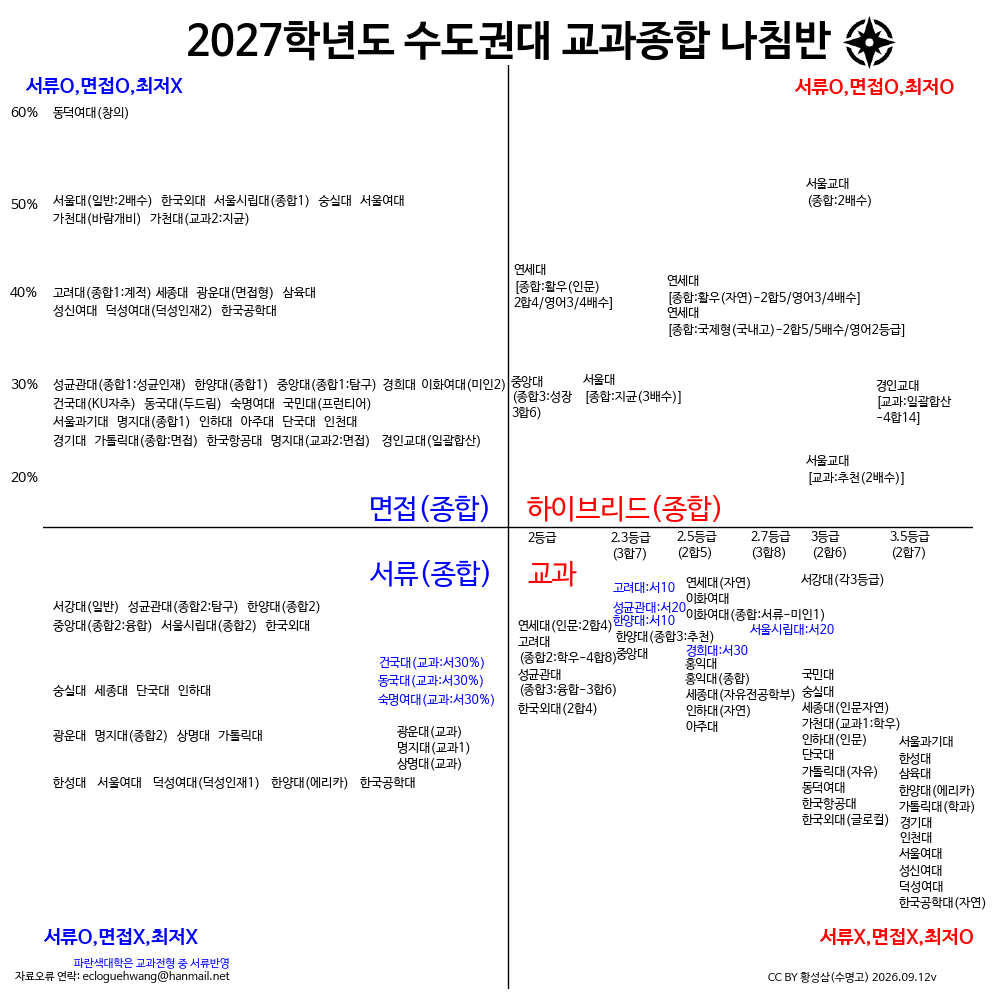

In [ ]:
#수능이전 면접대학 이텔릭으로 표현

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import time
from datetime import datetime
import pytz


#matplotlib에서 한글구현
plt.rc('font', family='NanumBarunGothic')

#그래프 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


# 서울의 현재시간
kst = pytz.timezone('Asia/Seoul')
current_datetime = datetime.now(kst).strftime('%Y.%m.%d')

# 그래프 크기 설정
fig, ax = plt.subplots(figsize=(12, 12))


# 사분면 구분선 그리기
ax.axhline(y=0.5, color='black', linewidth=1)
ax.axvline(x=0.5, color='black', linewidth=1)


# 사분면 제목 추가
ax.text(0.35, 0.51, '면접(종합)', fontsize=20, color='blue')
ax.text(0.52, 0.51, '하이브리드(종합)', fontsize=20, color='red')
ax.text(0.35, 0.44, '서류(종합)', fontsize=20, color='blue')
ax.text(0.52, 0.44, '교과', fontsize=20, color='red')


# 최저 없음 / 있음 표시
ax.text(-0.02, 0.971, '서류O,면접O,최저X', fontsize=14, color='blue', weight='bold', ha='left')
ax.text(0, 0.05, '서류O,면접X,최저X', fontsize=14, color='blue', weight='bold', ha='left')
ax.text(0.98, 0.97, '서류O,면접O,최저O', fontsize=14, color='red', weight='bold', ha='right')
ax.text(1, 0.05, '서류X,면접X,최저O', fontsize=14, color='red', weight='bold', ha='right')


#파란색 대학 설명
ax.text(0.2, 0.025, f'파란색대학은 교과전형 중 서류반영', fontsize=8, color='blue', ha='right')


# 자료 오류연락
ax.text(0.2, 0.01, f'자료오류 연락: ecloguehwang@hanmail.net', fontsize=8, color='black', ha='right')


# 저작자 표시
ax.text(0.96, 0.01, f'CC BY 황성삼(수명고) {current_datetime}v', fontsize=8, color='black', ha='right')


# Y축 라벨(값)은 유지하고 눈금만 제거
ax.set_yticks([0.555, 0.655, 0.755, 0.85, 0.95])  # Y축 위치 설정
ax.set_yticklabels(['20%', '30%', '40%', '50%', '60%'])  # Y축 라벨 설정
ax.tick_params(axis='y', length=0)  # Y축 눈금 선 제거


# X축 tick label 제거
ax.set_xticks([])  # X축 눈금 제거


# 파란색으로 표시할 대학 및 좌표 (정확히 지정)
blue_placements = [
    (0.36, 0.35, '건국대(교과:서30%)'),  # 예: 기존 좌표 (0.35, 0.35)에서 건국대(교과)만 파란색
    (0.36, 0.33, '동국대(교과:서30%)'),  # 예: 동국대(교과)의 새로운 좌표 (조정 필요)
    (0.36, 0.31, '숙명여대(교과:서30%)'),
    (0.612, 0.43, '고려대:서10'),   # 예: placements02에서 (0.6, 0.36)의 첫 줄
    (0.612, 0.41, '성균관대:서20'), # 예: 두 번째 줄 (조정 필요)
    (0.612, 0.395, '한양대:서10'),   # 예: 세 번째 줄 (조정 필요)
    (0.69, 0.363, '경희대:서30'),  # 예: placements02에서 (0.68, 0.28)의 두 번째 줄
    (0.76, 0.385, '서울시립대:서20')
]

# 파란색 텍스트 추가
for x, y, text in blue_placements:
    ax.text(x, y, text, fontsize= 9, color='blue')


# 이탤릭으로 표시할 대학 (수능 이전 면접) - '고려대(종합1:계적)'만 분리하여 이텔릭 처리
italic_placements = [
    (0.01, 0.75, '고려대(종합1:계적)'),
]

for x, y, text in italic_placements:
    ax.text(x, y, text, fontsize=9, color='black', fontstyle='italic')


# 나머지 대학 및 전형 정보 (검은색으로 표시)
placements = [
    (0.01, 0.945, '동덕여대(창의)'),
    (0.01, 0.85, '서울대(일반:2배수)   한국외대   서울시립대(종합1)   숭실대   서울여대'),
    (0.01, 0.83, '가천대(바람개비)   가천대(교과2:지균)'),
    (0.12, 0.75, '세종대   광운대(면접형)   삼육대'),  # '고려대(종합1:계적)'는 위 italic_placements로 분리
    (0.01, 0.73, '성신여대   덕성여대(덕성인재2)   한국공학대'),
    (0.01, 0.65, '성균관대(종합1:성균인재)   한양대(종합1)   중앙대(종합1:탐구)  경희대  이화여대(미인2)'),
    (0.01, 0.63, '건국대(KU자추)   동국대(두드림)   숙명여대   국민대(프런티어)'),
    (0.01, 0.61, '서울과기대   명지대(종합1)   인하대   아주대   단국대   인천대'),
    (0.01, 0.59, '경기대   가톨릭대(종합:면접)   한국항공대   명지대(교과2:면접)    경인교대(일괄합산)'),
    (0.505, 0.74, '연세대\n[종합:활우(인문)\n2합4/영어3/4배수]'),
    (0.82, 0.85, '서울교대\n(종합:2배수)'),
    (0.67, 0.71, '연세대\n[종합:활우(자연)-2합5/영어3/4배수]\n연세대\n[종합:국제형(국내고)-2합5/5배수/영어2등급]'),
    (0.503, 0.62, '중앙대\n(종합3:성장\n3합6)'),
    (0.58, 0.638, '서울대\n[종합:지균(3배수)]'),
    (0.82, 0.550, '서울교대\n[교과:추천(2배수)]'),
    (0.895, 0.615, '경인교대\n[교과:일괄합산\n-4합14]'),


    (0.01, 0.41, '서강대(일반)   성균관대(종합2:탐구)   한양대(종합2)'),
    (0.01, 0.39, '중앙대(종합2:융합)   서울시립대(종합2)   한국외대'),
    (0.01, 0.32, '숭실대   세종대   단국대   인하대'),
    (0.01, 0.27, '광운대   명지대(종합2)   상명대   가톨릭대'),

    (0.01, 0.22, '한성대    서울여대    덕성여대(덕성인재1)    한양대(에리카)    한국공학대'),

    (0.38, 0.24, '광운대(교과)\n명지대(교과1)\n상명대(교과)'),


    (0.52, 0.485, '2등급'),
    (0.61, 0.468, '2.3등급\n(3합7)'),
    (0.68, 0.469, '2.5등급\n(2합5)'),
    (0.76, 0.469, '2.7등급\n(3합8)'),
    (0.825, 0.469, '3등급\n(2합6)'),
    (0.91, 0.469, '3.5등급\n(2합7)')

]

# 검은색 텍스트 추가
for x, y, text in placements:
    ax.text(x, y, text, fontsize= 9, color='black')

# 추가 대학 및 전형 정보 (검은색으로 표시, blue_placements로 이미 처리된 부분 제외)
placements02 = [
    (0.51, 0.32, '연세대(인문:2합4)\n고려대\n(종합2:학우-4합8)\n성균관대\n(종합3:융합-3합6)'),
    (0.51, 0.30, '한국외대(2합4)'),
    (0.615, 0.36, '한양대(종합3:추천)\n중앙대'),  # "고려대", "성균관대", "한양대"는 blue_placements로 처리
    (0.69, 0.28, '연세대(자연)\n이화여대\n이화여대(종합:서류-미인1)\n\n\n홍익대\n홍익대(종합)\n세종대(자유전공학부)\n인하대(자연)\n아주대'),  # "경희대"는 blue_placements로 처리

    (0.815, 0.18, '서강대(각3등급)\n\n\n\n\n\n국민대\n숭실대\n세종대(인문자연)\n가천대(교과1:학우)\n인하대(인문)\n단국대\n가톨릭대(자유)\n동덕여대\n한국항공대\n한국외대(글로컬)'),
    (0.92, 0.09, '서울과기대\n한성대\n삼육대\n한양대(에리카)\n가톨릭대(학과)\n경기대\n인천대\n서울여대\n성신여대\n덕성여대\n한국공학대(자연)'),
]

# 검은색 텍스트 추가
for x, y, text in placements02:
    ax.text(x, y, text, fontsize= 9, color='black')

# 그래프 제목 설정
ax.set_title('2027학년도 수도권대 교과종합 나침반', fontsize= 30, weight='bold')



# 이미지 삽입
image_path = '/content/drive/MyDrive/python/jinhak/image/compass.png'
image = plt.imread(image_path)
imagebox = OffsetImage(image, zoom= 0.5)  # zoom으로 이미지 크기 조정
ab = AnnotationBbox(imagebox, (0.92, 1.06), xycoords='axes fraction', box_alignment=(1, 1), pad=0, frameon=False)
ax.add_artist(ab)


# 그래프 테두리(Spines) 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# 그래프 저장 (사진 파일로 결과 출력)
path2 = '/content/drive/MyDrive/python/jinhak/'
#plt.savefig(f'{path2}2027_수시나침반.png', bbox_inches='tight', dpi=300)

# 그래프 표시
plt.show()